# Figuras para la memoria: construcción del datacubo

Este cuaderno genera figuras reproducibles a partir del datacubo final de Galicia. Todas usan el producto canónico: 1 km × 1 km, periodo 2019-01-01 a 2023-11-26, 29.601 celdas activas y target oficial EGIF.

Las figuras se muestran con fondo blanco y están preparadas para exportarse a la memoria con `fig.savefig(..., dpi=300, bbox_inches='tight')`.

In [2]:
from pathlib import Path
import json

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
import xarray as xr

def find_project_root(start: Path) -> Path:
    """Localiza la raíz del repositorio aunque PyCharm ejecute desde notebooks/."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError(
        'No se ha localizado la raíz del proyecto. Abre el notebook dentro del repositorio.'
    )

ROOT = find_project_root(Path.cwd())

CUBE_PATH = ROOT / 'data/processed/datacube/galicia_1km.nc'
GRID_PATH = ROOT / 'data/processed/grid/galicia_grid_1km.gpkg'
BOUNDARY_PATH = ROOT / 'data/raw/igm/galicia_boundary.geojson'
METADATA_PATH = ROOT / 'data/processed/tabular/egif/metadata.json'

assert CUBE_PATH.exists(), f'No se encuentra {CUBE_PATH}'
assert GRID_PATH.exists(), f'No se encuentra {GRID_PATH}'

cube = xr.open_dataset(CUBE_PATH)
grid = gpd.read_file(GRID_PATH)
boundary = gpd.read_file(BOUNDARY_PATH).to_crs(grid.crs)
metadata = json.loads(METADATA_PATH.read_text(encoding='utf-8'))

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.dpi': 120,
})

extent = (float(cube.x.min()) - 500, float(cube.x.max()) + 500,
          float(cube.y.min()) - 500, float(cube.y.max()) + 500)
active = cube['is_galicia'].values.astype(bool)

def map_layer(ax, values, title, cmap='viridis', unit='', vmin=None, vmax=None):
    """Dibuja una capa xarray (y, x) sobre la misma referencia cartográfica."""
    layer = np.ma.masked_where(~active | ~np.isfinite(values), values)
    image = ax.imshow(layer, origin='lower', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    boundary.boundary.plot(ax=ax, color='#202020', linewidth=0.65)
    ax.set(title=title, xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
    ax.set_aspect('equal')
    colorbar = plt.colorbar(image, ax=ax, shrink=.78, pad=.02)
    if unit:
        colorbar.set_label(unit)
    return image


## 1. Dominio espacial: rectángulo regular y máscara de Galicia

El NetCDF mantiene el rectángulo completo porque permite almacenar capas homogéneas `(y, x)` y `(time, y, x)`. La máscara `is_galicia` identifica las celdas modelables; al exportar a Parquet solo se conservan estas celdas.

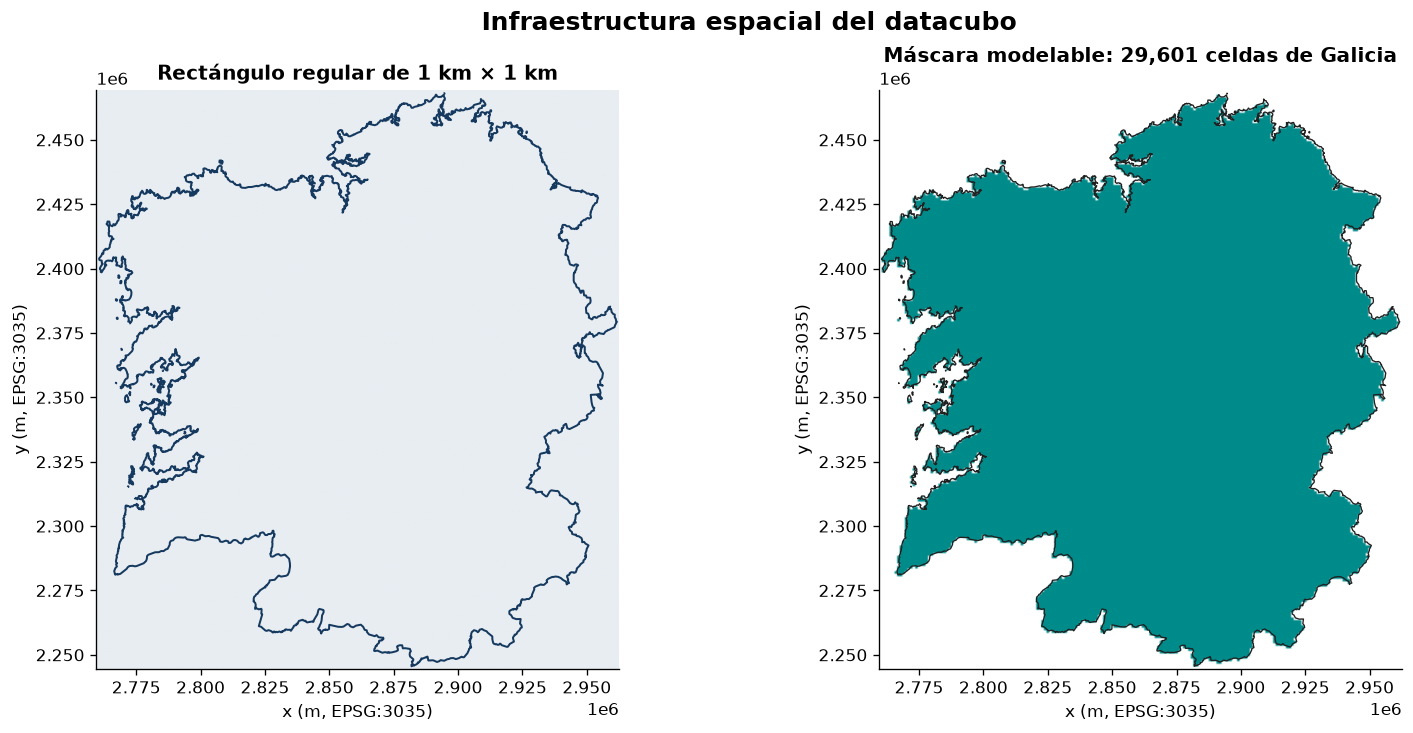

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)

axes[0].imshow(np.ones_like(active), origin='lower', extent=extent, cmap=ListedColormap(['#e8edf2']))
boundary.boundary.plot(ax=axes[0], color='#163a5f', linewidth=1.2)
axes[0].set(title='Rectángulo regular de 1 km × 1 km', xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
axes[0].set_aspect('equal')

mask = np.ma.masked_where(~active, active.astype(float))
axes[1].imshow(mask, origin='lower', extent=extent, cmap=ListedColormap(['#008b8b']))
boundary.boundary.plot(ax=axes[1], color='#202020', linewidth=.8)
axes[1].set(title=f'Máscara modelable: {int(active.sum()):,} celdas de Galicia', xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
axes[1].set_aspect('equal')

fig.suptitle('Infraestructura espacial del datacubo', fontsize=15, fontweight='bold')
plt.show()

## 2. Capas estáticas: topografía, combustible y actividad humana

Estas variables se calculan una vez por celda y no se repiten en el eje temporal. La topografía procede del Copernicus DEM; la cobertura del suelo, de CORINE 2018; y los indicadores de accesibilidad y ocupación, de una instantánea versionada de OpenStreetMap de 2022.

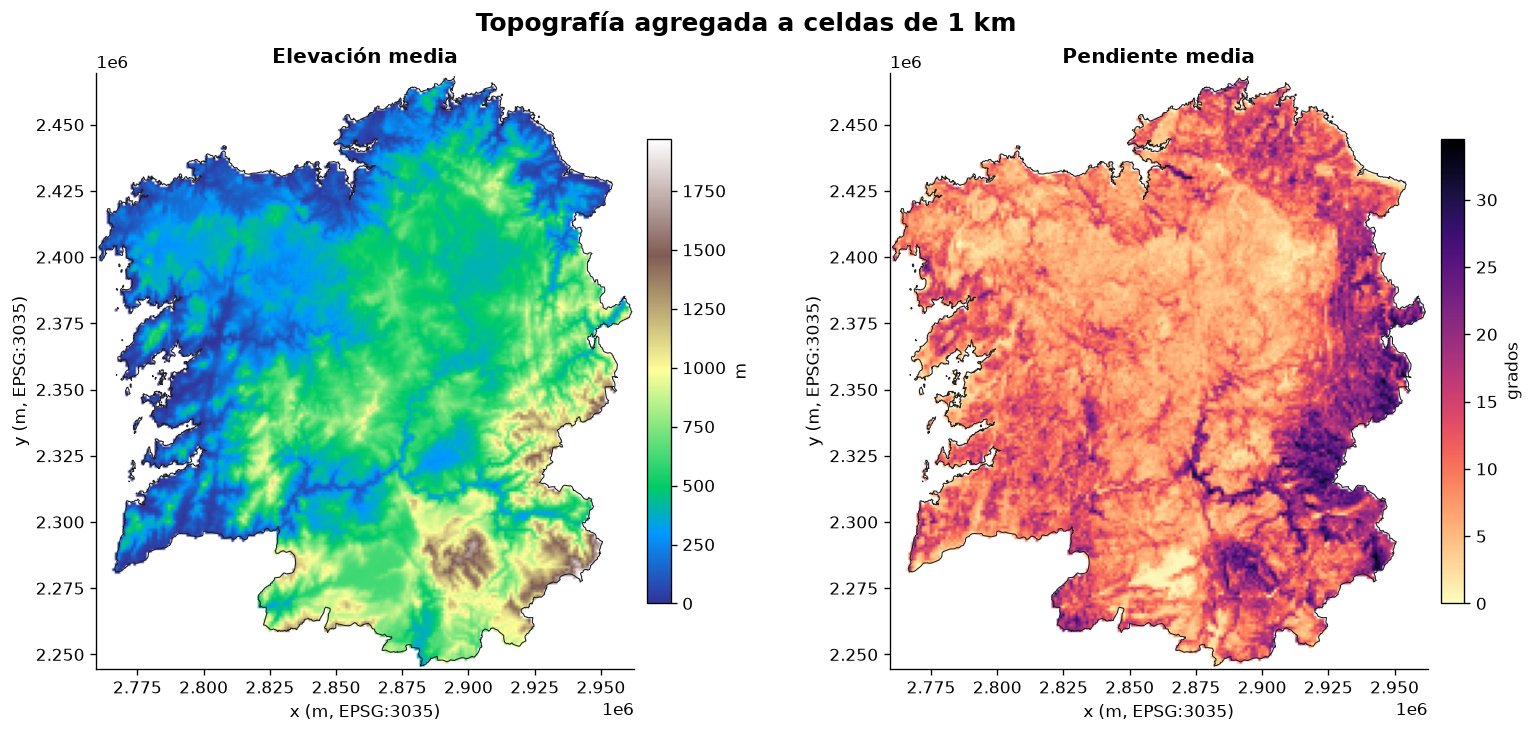

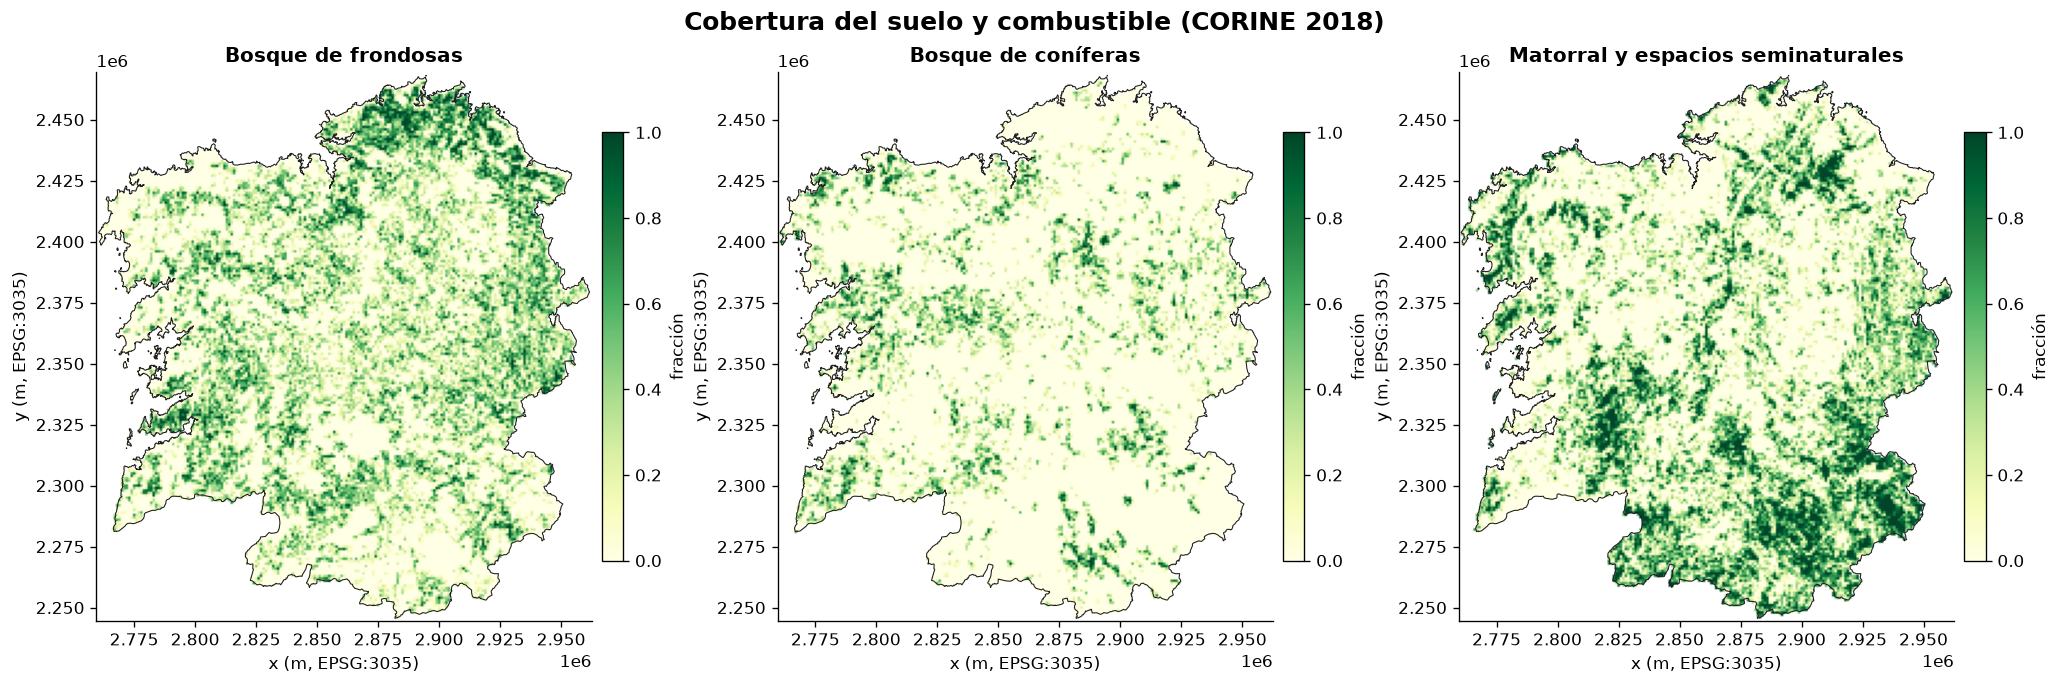

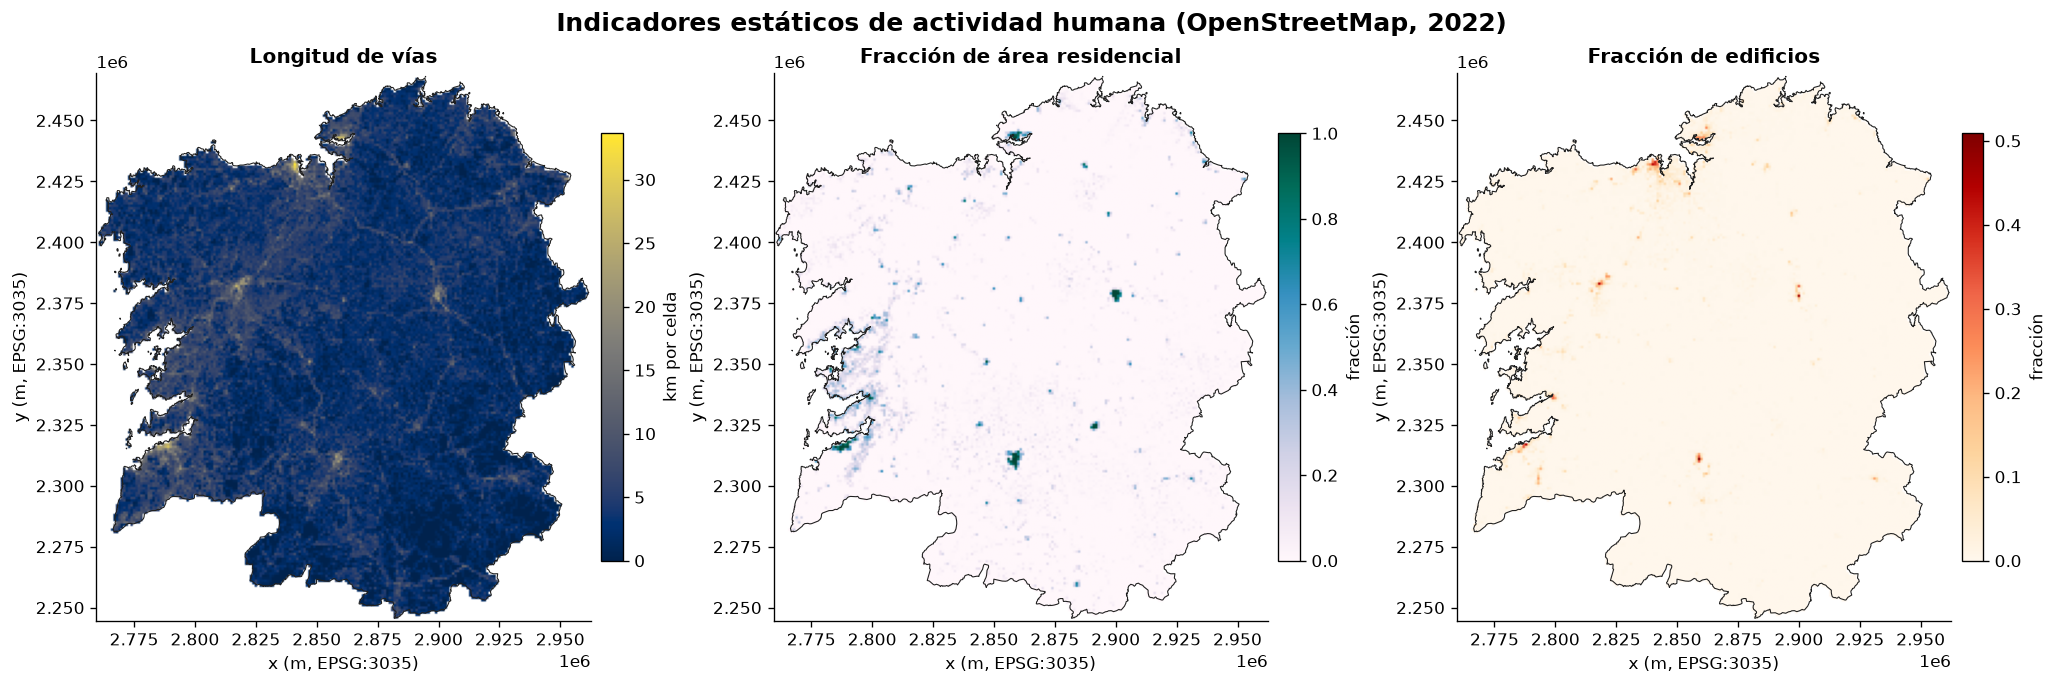

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
map_layer(axes[0], cube['elevation_mean'].values, 'Elevación media', 'terrain', 'm')
map_layer(axes[1], cube['slope_mean'].values, 'Pendiente media', 'magma_r', 'grados')
fig.suptitle('Topografía agregada a celdas de 1 km', fontsize=15, fontweight='bold')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6), constrained_layout=True)
for ax, variable, title in zip(axes, ['broadleaf_forest', 'coniferous_forest', 'scrub'],
                               ['Bosque de frondosas', 'Bosque de coníferas', 'Matorral y espacios seminaturales']):
    map_layer(ax, cube[variable].values, title, 'YlGn', 'fracción', 0, 1)
fig.suptitle('Cobertura del suelo y combustible (CORINE 2018)', fontsize=15, fontweight='bold')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6), constrained_layout=True)
for ax, variable, title, cmap, unit in zip(axes,
    ['road_length_km', 'residential_area_fraction', 'building_area_fraction'],
    ['Longitud de vías', 'Fracción de área residencial', 'Fracción de edificios'],
    ['cividis', 'PuBuGn', 'OrRd'], ['km por celda', 'fracción', 'fracción']):
    map_layer(ax, cube[variable].values, title, cmap, unit)
fig.suptitle('Indicadores estáticos de actividad humana (OpenStreetMap, 2022)', fontsize=15, fontweight='bold')
plt.show()

## 3. Capas dinámicas: condiciones meteorológicas y objetivo EGIF

Las variables de ERA5-Land se agregan diariamente y se interpolan a la rejilla de 1 km. Se escoge automáticamente el día con más celdas-día positivas EGIF para mostrar conjuntamente la situación meteorológica y las igniciones observadas.

Día seleccionado: 2022-07-14 (55 celdas con ignición EGIF)


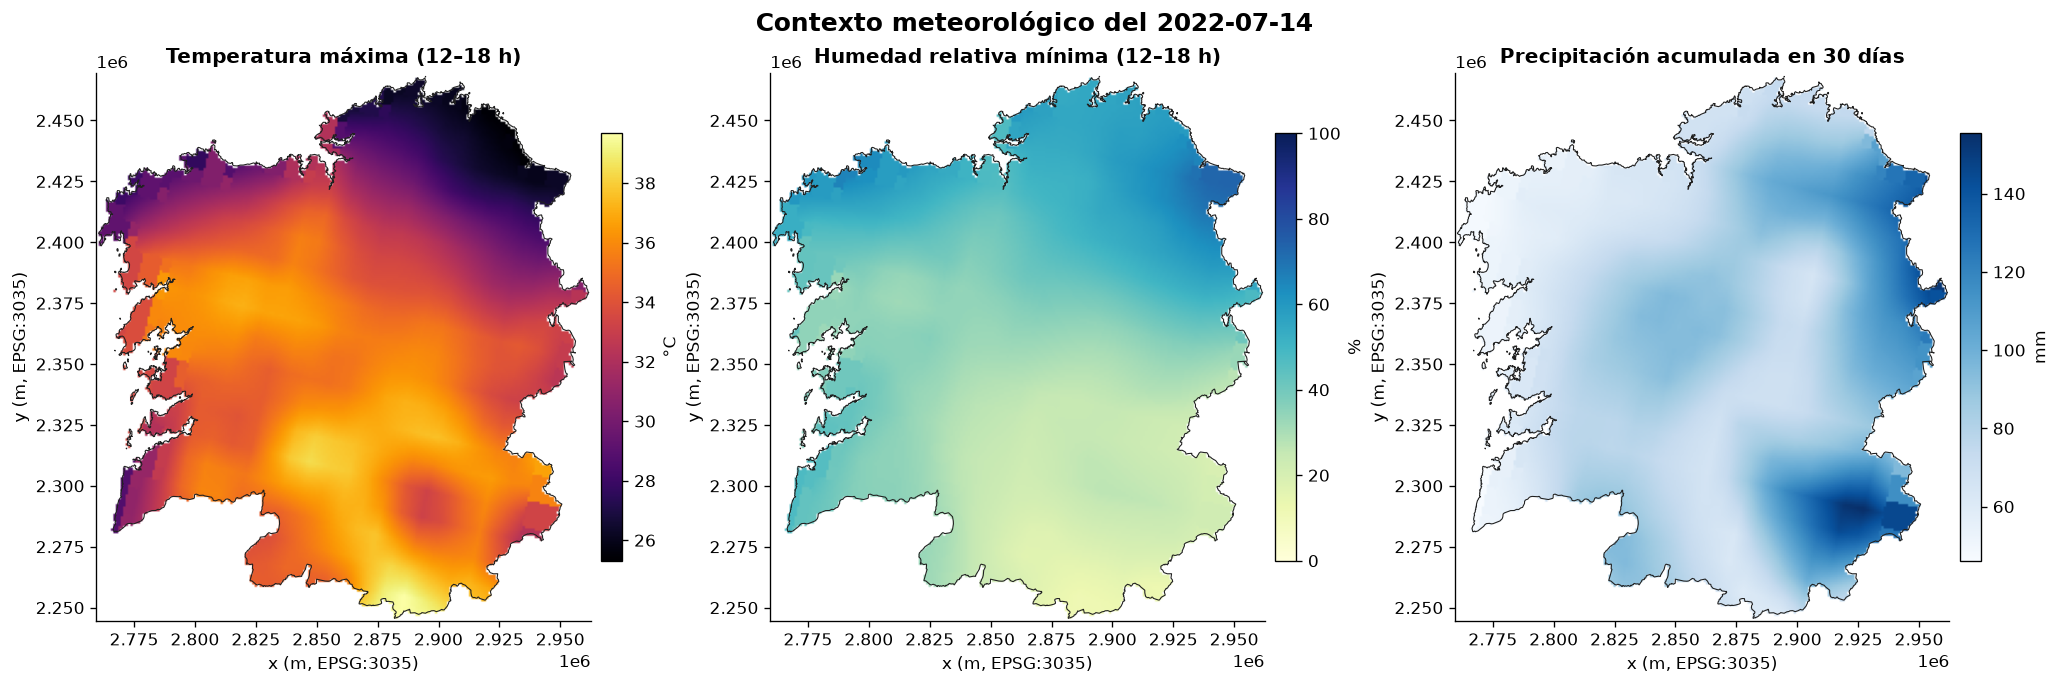

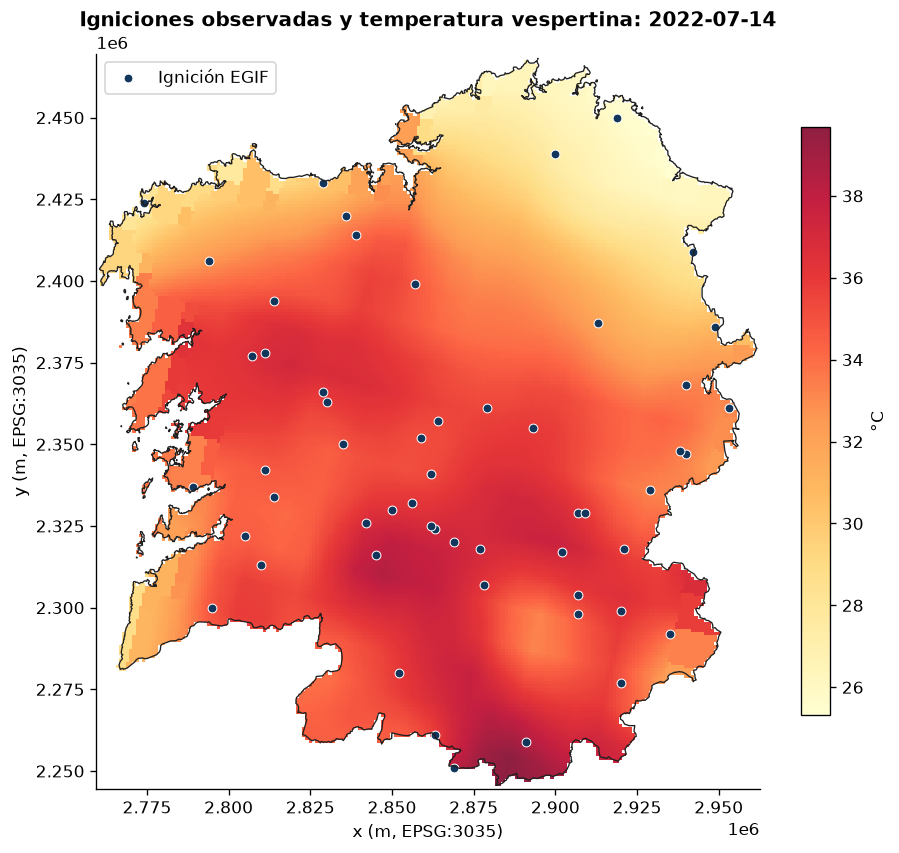

In [5]:
daily_ignitions = cube['target_ignicion'].sum(dim=('y', 'x'))
event_date = pd.Timestamp(daily_ignitions.idxmax().item())
n_ignitions = int(daily_ignitions.max().item())
print(f'Día seleccionado: {event_date.date()} ({n_ignitions} celdas con ignición EGIF)')

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6), constrained_layout=True)
map_layer(axes[0], cube['temperature_max_12_18h'].sel(time=event_date).values,
          'Temperatura máxima (12–18 h)', 'inferno', '°C')
map_layer(axes[1], cube['relative_humidity_min_12_18h'].sel(time=event_date).values,
          'Humedad relativa mínima (12–18 h)', 'YlGnBu', '%', 0, 100)
map_layer(axes[2], cube['precipitation_sum_30d'].sel(time=event_date).values,
          'Precipitación acumulada en 30 días', 'Blues', 'mm')
fig.suptitle(f'Contexto meteorológico del {event_date.date()}', fontsize=15, fontweight='bold')
plt.show()

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
risk_background = np.ma.masked_where(~active, cube['temperature_max_12_18h'].sel(time=event_date).values)
image = ax.imshow(risk_background, origin='lower', extent=extent, cmap='YlOrRd', alpha=.88)
fires = cube['target_ignicion'].sel(time=event_date).values == 1
rows, cols = np.where(fires)
ax.scatter(cube.x.values[cols], cube.y.values[rows], s=28, color='#12355b', edgecolor='white', linewidth=.6, label='Ignición EGIF')
boundary.boundary.plot(ax=ax, color='#202020', linewidth=.8)
ax.set(title=f'Igniciones observadas y temperatura vespertina: {event_date.date()}', xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
ax.legend(loc='upper left', frameon=True)
plt.colorbar(image, ax=ax, shrink=.8, label='°C')
plt.show()

## 4. Eje temporal, volumen de datos y arquitectura

El gráfico temporal ayuda a justificar la resolución diaria y el fuerte desbalance del problema. El esquema final sintetiza cómo las capas estáticas y dinámicas se combinan en un único producto NetCDF y se exportan después a Parquet para el modelado tabular.

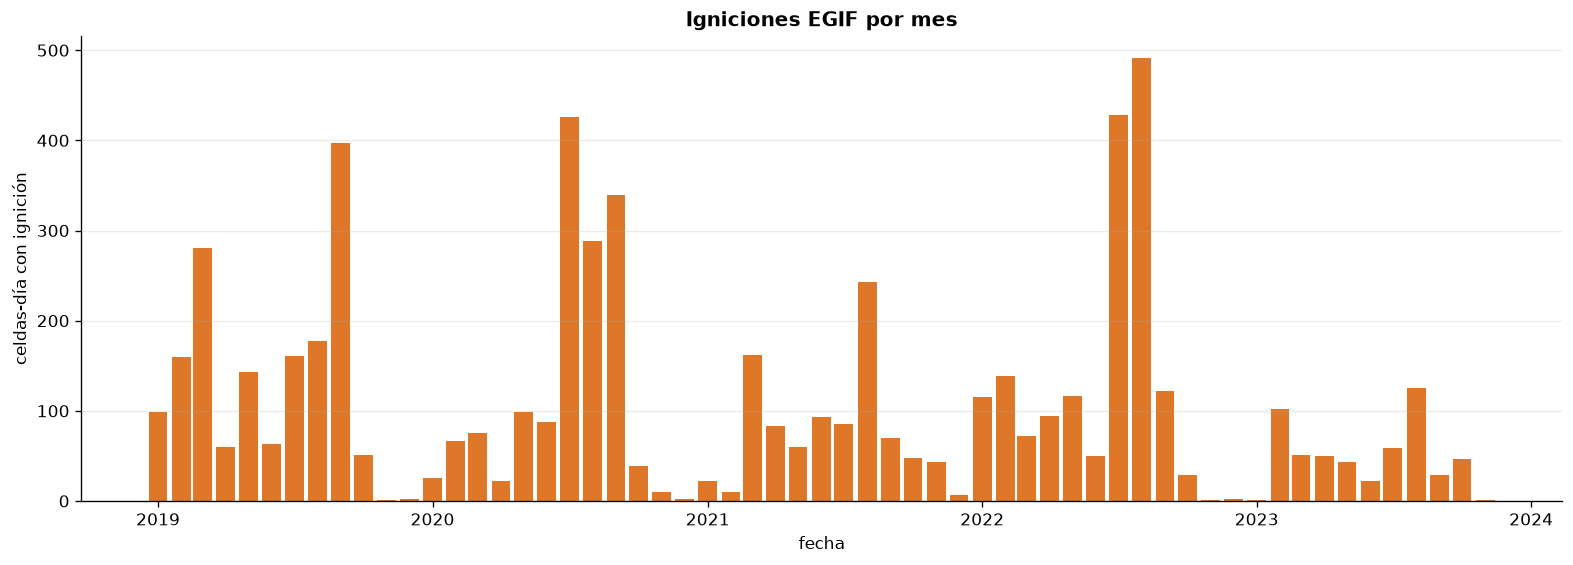

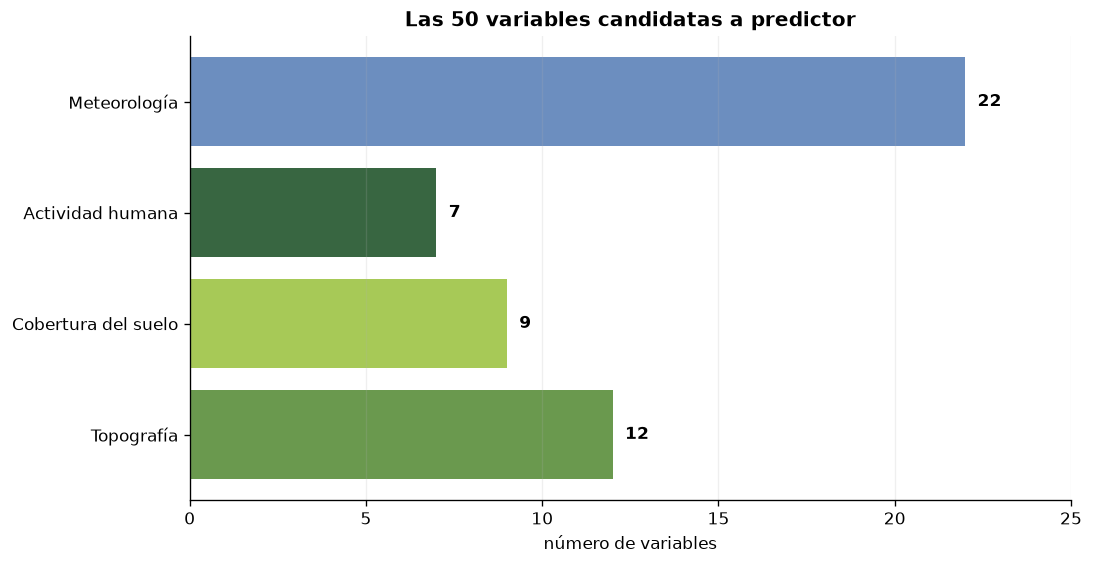

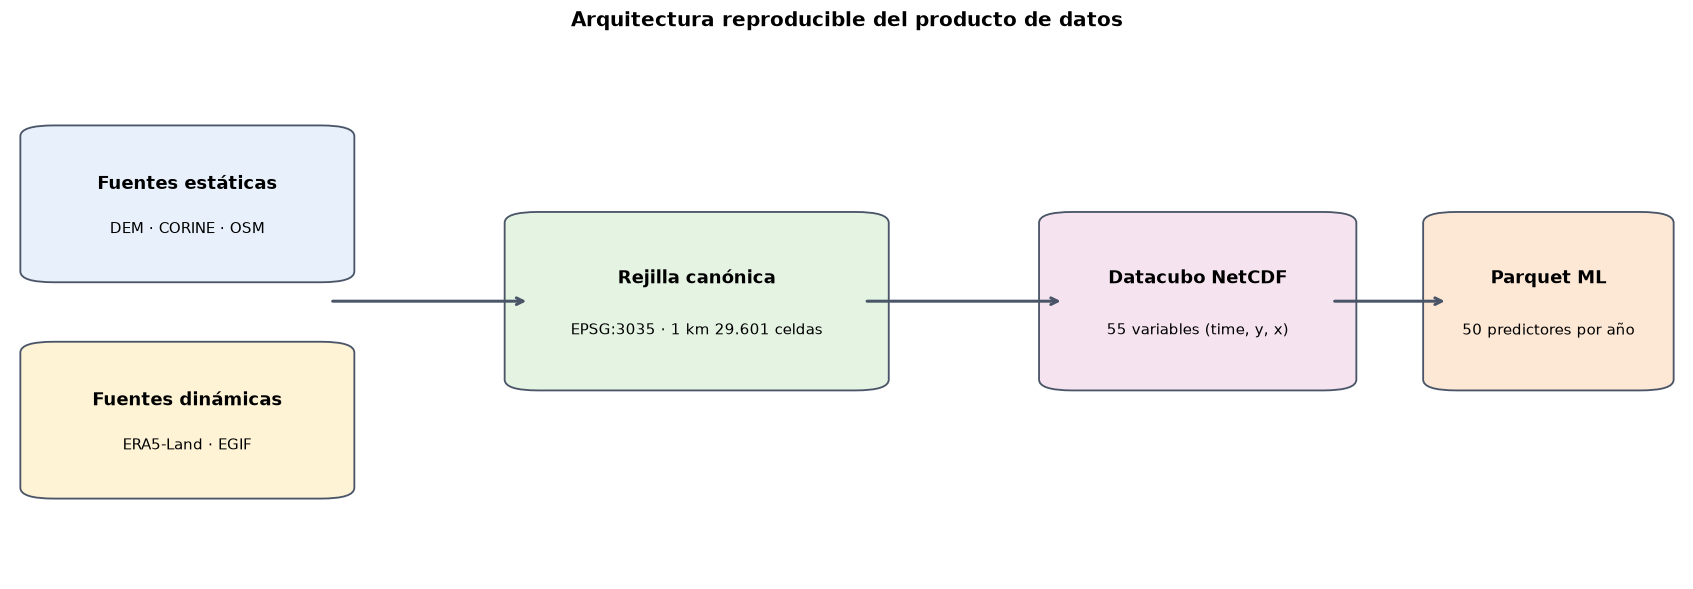

Periodo: 2019-01-01 → 2023-11-26
Filas Parquet: 53,015,391
Predictores publicados: 50
Identificadores de trazabilidad exportados: fecha, x, y, cell_id, year (no predictivos).


In [7]:
daily = daily_ignitions.to_pandas()
monthly = daily.resample('MS').sum()

fig, ax = plt.subplots(figsize=(13, 4.6), constrained_layout=True)
ax.bar(monthly.index, monthly.values, width=25, color='#d95f02', alpha=.85)
ax.set(title='Igniciones EGIF por mes', xlabel='fecha', ylabel='celdas-día con ignición')
ax.grid(axis='y', alpha=.25)
plt.show()

groups = {'Topografía': 12, 'Cobertura del suelo': 9, 'Actividad humana': 7, 'Meteorología': 22}
fig, ax = plt.subplots(figsize=(9, 4.6), constrained_layout=True)
bars = ax.barh(list(groups), list(groups.values()), color=['#6a994e', '#a7c957', '#386641', '#6c8ebf'])
for bar, value in zip(bars, groups.values()):
    ax.text(value + .35, bar.get_y() + bar.get_height()/2, str(value), va='center', fontweight='bold')
ax.set(title='Las 50 variables candidatas a predictor', xlabel='número de variables', xlim=(0, 25))
ax.grid(axis='x', alpha=.2)
plt.show()

fig, ax = plt.subplots(figsize=(14, 4.8), constrained_layout=True)
ax.axis('off')
boxes = [
    (0.02, .56, .17, .26, '#e8f1fb', 'Fuentes estáticas', 'DEM · CORINE · OSM'),
    (0.02, .16, .17, .26, '#fff3d6', 'Fuentes dinámicas', 'ERA5-Land · EGIF'),
    (.31, .36, .20, .30, '#e4f3e2', 'Rejilla canónica', 'EPSG:3035 · 1 km 29.601 celdas'),
    (.63, .36, .16, .30, '#f5e4ef', 'Datacubo NetCDF', '55 variables (time, y, x)'),
    (.86, .36, .12, .30, '#fce8d5', 'Parquet ML', '50 predictores por año'),
]
for x, y, w, h, color, title, subtitle in boxes:
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.015,rounding_size=.02', facecolor=color, edgecolor='#4a5568', linewidth=1.1))
    ax.text(x + w/2, y + h*.64, title, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(x + w/2, y + h*.32, subtitle, ha='center', va='center', fontsize=9)
for x0, x1 in [(0.19, .31), (.51, .63), (.79, .86)]:
    ax.annotate('', xy=(x1, .51), xytext=(x0, .51), arrowprops=dict(arrowstyle='->', lw=1.8, color='#4a5568'))
ax.set(title='Arquitectura reproducible del producto de datos')
plt.show()

print(f"Periodo: {str(cube.time.min().values)[:10]} → {str(cube.time.max().values)[:10]}")
print(f"Filas Parquet: {sum(metadata['annual_files'].values()):,}")
print(f"Predictores publicados: {len(metadata['predictor_columns'])}")
print('Identificadores de trazabilidad exportados: fecha, x, y, cell_id, year (no predictivos).')